# Эффект Талбота: рабочий ноутбук для моделирования

Этот ноутбук нужен не только для чтения, а для самостоятельных запусков: здесь можно менять параметры решетки и сразу смотреть, как меняется ковер Талбота.

Что удобно менять:

- `grating_kind`: `"amplitude"`, `"phase"` или `"hybrid"`;
- `profile`: форма решетки, например `"binary"`, `"multi_slit"`, `"sinusoidal"`, `"blazed"`;
- `slit_count`: число отверстий/щелей в одном периоде для `profile = "multi_slit"`;
- `model`: `"paraxial"` или `"exact"`;
- `wavelength_nm`, `period_um`, `Nx`, `Nz`, `num_periods`: параметры сетки и опыта.

Быстрый сценарий работы:

1. Выполнить ячейки импорта и функций.
2. Изменить параметры в разделе **Главная панель параметров**.
3. Запустить все ячейки ниже этой панели.
4. Для другого случая снова изменить параметры и повторить запуск.

Примеры:

- три щели в периоде: `grating_kind = "amplitude"`, `profile = "multi_slit"`, `slit_count = 3`;
- пять щелей в периоде: поменять `slit_count = 5`;
- фазовая пилообразная решетка: `grating_kind = "phase"`, `profile = "blazed"`; для красивого ковра оставьте `phase_depth` не равным ровно `2*np.pi`;
- синусоидальная фазовая решетка: `grating_kind = "phase"`, `profile = "sinusoidal"`;
- сравнение точной модели: поставить `model = "exact"` или выполнить специальный раздел сравнения ниже.


## Теоретический минимум

Для тонкой периодической решетки поле сразу после экрана записывается как

$$U(x,0)=t(x).$$

Периодическая функция пропускания раскладывается в ряд Фурье:

$$t(x)=\sum_m c_m \exp\left(i\frac{2\pi m}{d}x\right).$$

В параксиальном приближении каждая пространственная гармоника получает квадратичную фазу:

$$\exp\left(-i\pi m^2\frac{\lambda z}{d^2}\right).$$

При

$$z_T=\frac{2d^2}{\lambda}$$

фазы всех порядков снова согласуются, и возникает самовоспроизведение. При $z_T/2$ картина восстанавливается со сдвигом на $d/2$. На дробных расстояниях возникают дополнительные подструктуры.


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

PROJECT_ROOT


PosixPath('.')

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from talbot import (
    SimulationGrid,
    best_shift_correlation,
    binary_amplitude_grating,
    binary_phase_grating,
    blazed_phase_grating,
    hybrid_amplitude_phase_grating,
    multi_slit_amplitude_grating,
    multiharmonic_phase_grating,
    normalized_correlation,
    propagate_angular_spectrum,
    propagate_exact,
    propagate_paraxial,
    relative_l2_error,
    sinusoidal_amplitude_grating,
    sinusoidal_phase_grating,
    talbot_length,
    total_power,
    triangular_amplitude_grating,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## Главная панель параметров

Меняйте значения в этой ячейке. После изменения удобно выбрать в меню Jupyter: **Run → Run All Below**.

Допустимые варианты:

- `grating_kind = "amplitude"`: `profile` может быть `"binary"`, `"sinusoidal"`, `"triangular"`, `"multi_slit"`;
- `grating_kind = "phase"`: `profile` может быть `"sinusoidal"`, `"binary"`, `"blazed"`, `"multiharmonic"`;
- `grating_kind = "hybrid"`: `profile = "sinusoidal"`;
- `model = "paraxial"` быстрее, `model = "exact"` учитывает непараксиальную фазу углового спектра.


In [4]:
# Физические параметры
wavelength_nm = 532.0
period_um = 40.0

# Сетка. Для быстрых экспериментов оставьте эти значения.
# Для более гладких картинок можно увеличить Nx и Nz, например Nx=8192, Nz=500.
num_periods = 32
Nx = 4096
Nz = 240
z_max_talbot = 1.0

# Выбор решетки и модели распространения
grating_kind = "amplitude"     # "amplitude", "phase", "hybrid"
profile = "multi_slit"         # см. список допустимых вариантов выше
model = "paraxial"             # "paraxial" или "exact"
keep_evanescent = True          # используется только в точной модели

# Параметры амплитудных решеток
fill = 0.50                    # доля открытого окна для binary
modulation = 0.35              # глубина синусоидальной амплитудной модуляции
contrast = 1.0                 # контраст треугольной амплитудной решетки
slit_count = 5                 # число отверстий/щелей в периоде для multi_slit
slit_width = 0.10              # ширина каждой щели в долях периода

# Параметры фазовых решеток
phi0 = np.pi / 2               # глубина синусоидальной фазы
phase_step = np.pi             # скачок фазы для binary phase
phase_depth = 1.35 * np.pi     # нецелый ход фазы для blazed: так ковер не вырождается в почти однородный

# Что показывать по x на графиках, в периодах решетки
x_window_periods = 8

wavelength = wavelength_nm * 1e-9
period = period_um * 1e-6

grid = SimulationGrid(
    wavelength=wavelength,
    period=period,
    num_periods=num_periods,
    nx=Nx,
    nz=Nz,
)

x = grid.x
zT = grid.z_talbot
z_values = np.linspace(0.0, z_max_talbot * zT, Nz)

print(f"Тип решетки: {grating_kind}, профиль: {profile}")
print(f"Модель распространения: {model}")
print(f"lambda = {wavelength_nm:.1f} нм, d = {period_um:.1f} мкм")
print(f"z_T = {zT * 1e3:.3f} мм")
print(f"Окно: {num_periods} периодов, Nx = {Nx}, Nz = {Nz}")
print(f"dx = {grid.dx * 1e9:.1f} нм")


Тип решетки: amplitude, профиль: multi_slit
Модель распространения: paraxial
lambda = 532.0 нм, d = 40.0 мкм
z_T = 6.015 мм
Окно: 32 периодов, Nx = 4096, Nz = 240
dx = 312.5 нм


## Функции ноутбука

Эти функции строят выбранную решетку, считают ковер Талбота, показывают профиль, спектр и срезы интенсивности. Обычно их не нужно менять.


In [5]:
def intensity(u):
    return np.abs(u) ** 2


def normalize(a):
    a = np.asarray(a, dtype=float)
    m = np.max(a)
    return a / m if m > 0 else a


def make_grating(x, period):
    """Build the grating selected in the parameter cell."""

    if grating_kind == "amplitude":
        if profile == "binary":
            return binary_amplitude_grating(x, period, fill=fill)
        if profile == "sinusoidal":
            return sinusoidal_amplitude_grating(x, period, modulation=modulation)
        if profile == "triangular":
            return triangular_amplitude_grating(x, period, contrast=contrast)
        if profile == "multi_slit":
            return multi_slit_amplitude_grating(
                x,
                period,
                slit_count=int(slit_count),
                slit_width=slit_width,
            )
        raise ValueError("Для amplitude доступны: binary, sinusoidal, triangular, multi_slit")

    if grating_kind == "phase":
        if profile == "sinusoidal":
            return sinusoidal_phase_grating(x, period, phi0=phi0)
        if profile == "binary":
            return binary_phase_grating(x, period, fill=fill, phase_step=phase_step)
        if profile == "blazed":
            return blazed_phase_grating(x, period, phase_depth=phase_depth)
        if profile == "multiharmonic":
            return multiharmonic_phase_grating(x, period, phi0=phi0)
        raise ValueError("Для phase доступны: sinusoidal, binary, blazed, multiharmonic")

    if grating_kind == "hybrid":
        if profile != "sinusoidal":
            raise ValueError("Для hybrid оставьте profile = 'sinusoidal'")
        return hybrid_amplitude_phase_grating(x, period, modulation=modulation, phi0=phi0)

    raise ValueError("grating_kind должен быть amplitude, phase или hybrid")


def propagate(field, z, local_grid=grid):
    return propagate_angular_spectrum(
        field,
        local_grid.dx,
        local_grid.wavelength,
        float(z),
        model=model,
        keep_evanescent=keep_evanescent,
    )


def talbot_carpet(field, local_grid=grid, local_z_values=z_values):
    rows = []
    for z in local_z_values:
        rows.append(intensity(propagate(field, z, local_grid)))
    carpet = np.asarray(rows)
    max_value = carpet.max()
    return carpet / max_value if max_value > 0 else carpet


def x_mask(local_grid=grid, half_width_periods=x_window_periods):
    local_x = local_grid.x
    return np.abs(local_x / local_grid.period) <= half_width_periods / 2


def plot_transmission(field, local_grid=grid):
    mask = x_mask(local_grid)
    local_x = local_grid.x
    fig, axes = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True)
    axes[0].plot(local_x[mask] / local_grid.period, np.abs(field[mask]), color="#2b6f8a")
    axes[0].set_ylabel(r"$|t(x)|$")
    axes[0].set_title("Модуль пропускания")
    axes[1].plot(local_x[mask] / local_grid.period, np.unwrap(np.angle(field[mask])), color="#9b4dca")
    axes[1].set_ylabel("Фаза, рад")
    axes[1].set_xlabel(r"$x/d$")
    axes[1].set_title("Фаза пропускания")
    fig.tight_layout()
    return fig


def plot_carpet(carpet, local_grid=grid, local_z_values=z_values, title=None, cmap="magma"):
    mask = x_mask(local_grid)
    extent = (
        local_grid.x[mask][0] / local_grid.period,
        local_grid.x[mask][-1] / local_grid.period,
        local_z_values[0] / local_grid.z_talbot,
        local_z_values[-1] / local_grid.z_talbot,
    )
    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    im = ax.imshow(
        carpet[:, mask],
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=cmap,
        vmin=0,
        vmax=np.percentile(carpet[:, mask], 99.5),
    )
    ax.set_xlabel(r"$x/d$")
    ax.set_ylabel(r"$z/z_T$")
    ax.set_title(title or f"Ковер Талбота: {grating_kind}, {profile}")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Нормированная интенсивность")
    fig.tight_layout()
    return fig


def plot_slices(field, positions=(0.0, 0.25, 0.5, 1.0), local_grid=grid):
    mask = x_mask(local_grid)
    fig, ax = plt.subplots(figsize=(9, 4.2))
    for pos in positions:
        uz = propagate(field, pos * local_grid.z_talbot, local_grid)
        ax.plot(local_grid.x[mask] / local_grid.period, normalize(intensity(uz))[mask], label=rf"$z/z_T={pos:g}$")
    ax.set_xlabel(r"$x/d$")
    ax.set_ylabel("Нормированная интенсивность")
    ax.set_title("Срезы интенсивности")
    ax.legend(ncol=2)
    fig.tight_layout()
    return fig


def plot_spectrum(field, local_grid=grid, order_limit=16):
    spectrum = np.fft.fftshift(np.fft.fft(field)) / field.size
    orders = np.fft.fftshift(np.fft.fftfreq(field.size, d=local_grid.dx)) * local_grid.period
    mask = np.abs(orders) <= order_limit
    fig, ax = plt.subplots(figsize=(9, 3.8))
    ax.stem(orders[mask], np.abs(spectrum[mask]) ** 2, basefmt=" ")
    ax.set_yscale("log")
    ax.set_ylim(1e-8, max(1.5, np.max(np.abs(spectrum[mask]) ** 2) * 1.4))
    ax.set_xlabel(r"Номер порядка $m=f_x d$")
    ax.set_ylabel(r"$|c_m|^2$")
    ax.set_title("Спектр пространственных частот")
    fig.tight_layout()
    return fig


## Текущая решетка

Эта ячейка строит решетку по параметрам из главной панели и показывает ее модуль и фазу. Для чисто фазовой решетки модуль почти постоянен, а весь эффект появляется после распространения.


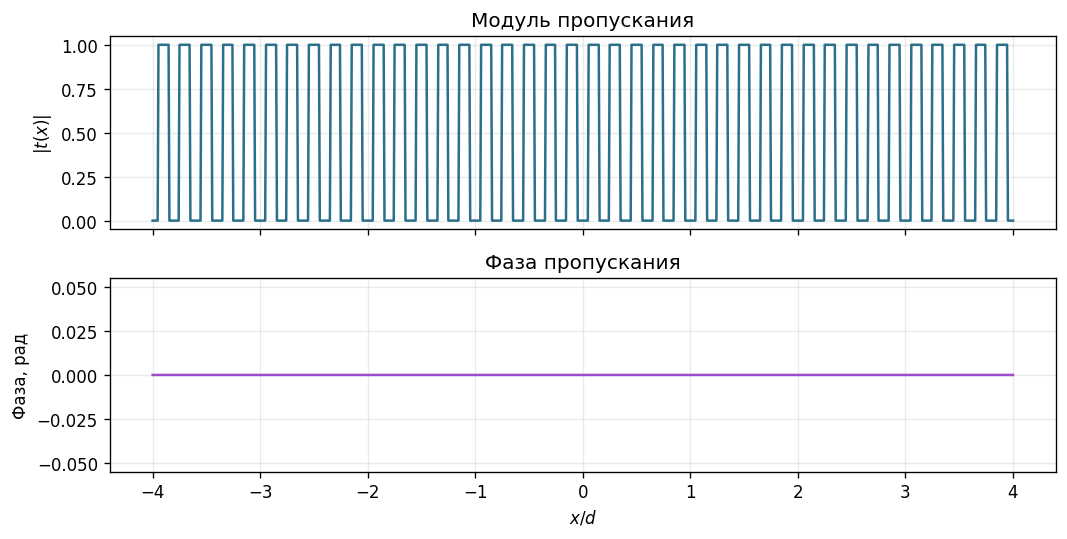

In [6]:
field = make_grating(x, period)
fig = plot_transmission(field)
plt.show()


## Ковер Талбота для выбранных параметров

Здесь рассчитывается интенсивность $|U(x,z)|^2$ на сетке расстояний. Если меняете `Nx` и `Nz`, время выполнения этой ячейки меняется сильнее всего.


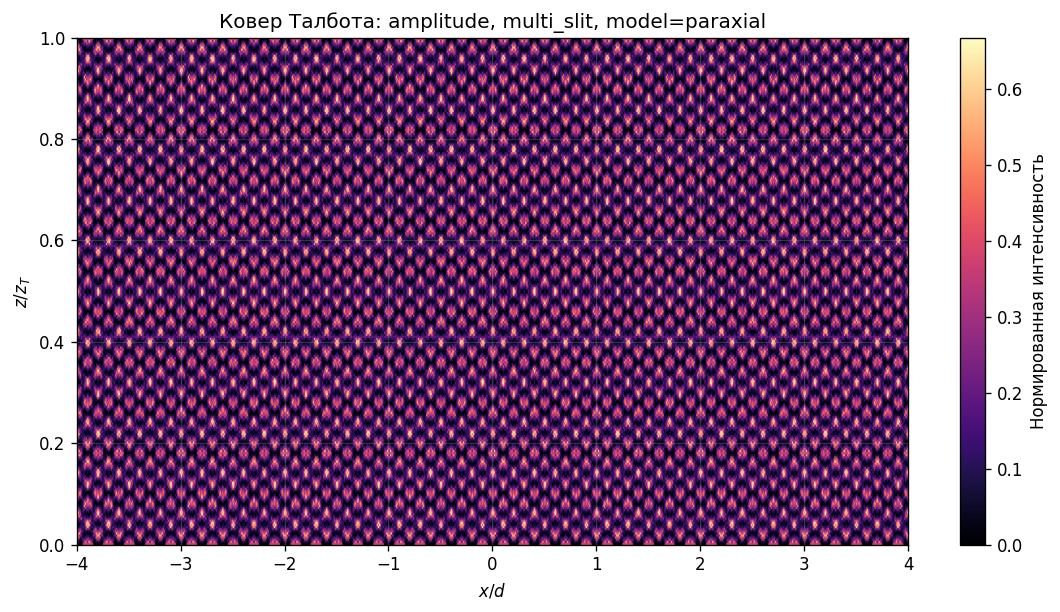

In [7]:
carpet = talbot_carpet(field)
fig = plot_carpet(carpet, title=f"Ковер Талбота: {grating_kind}, {profile}, model={model}")
plt.show()


## Срезы интенсивности

На этих графиках удобно проверять самовоспроизведение. Для амплитудной периодической решетки около $z_T$ должна появляться картина, близкая к исходной. На $z_T/2$ восстановление происходит со сдвигом на половину периода.


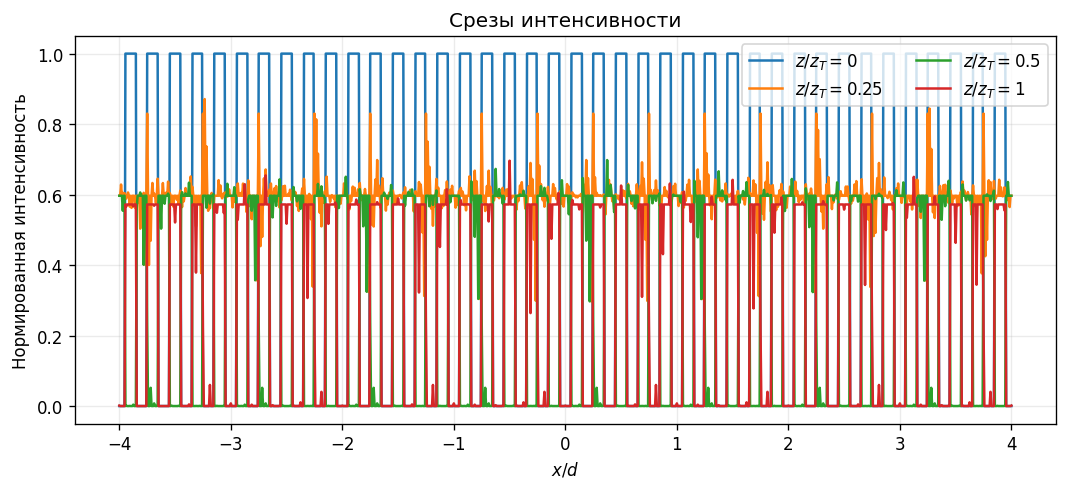

In [8]:
fig = plot_slices(field)
plt.show()


## Спектр решетки

Чем больше заметных пространственных гармоник в спектре, тем богаче интерференционная картина в ковре. Бинарные и многощелевые ячейки обычно дают более широкий спектр, чем гладкие синусоидальные.


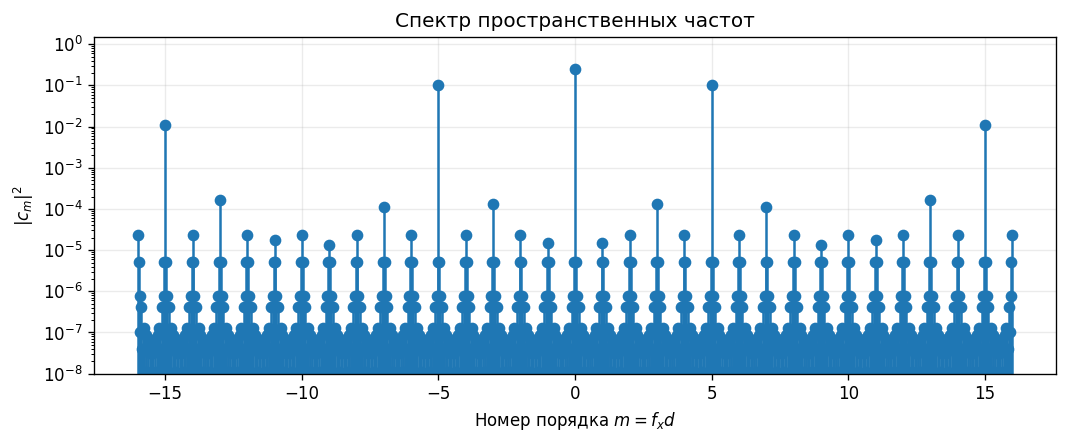

In [9]:
fig = plot_spectrum(field)
plt.show()


## Численные проверки для текущей решетки

Для фазовых решеток интенсивность в плоскости $z=0$ может быть почти однородной, поэтому корреляции интенсивности не всегда выглядят так же выразительно, как для амплитудных решеток. Для амплитудных решеток восстановление при $z_T$ обычно видно напрямую.


In [10]:
u0 = field
uT = propagate(u0, zT)
uHalf = propagate(u0, zT / 2)

samples_per_period = max(1, grid.nx // grid.num_periods)
shift_half_period = samples_per_period // 2
shifted_intensity = np.roll(intensity(u0), shift_half_period)

print(f"Мощность при z=0:   {total_power(u0, grid.dx):.6e}")
print(f"Мощность при z=zT:  {total_power(uT, grid.dx):.6e}")
print(f"Относительное изменение мощности: {abs(total_power(uT, grid.dx) / total_power(u0, grid.dx) - 1):.3e}")
print(f"Корреляция I(0) и I(zT):          {normalized_correlation(intensity(u0), intensity(uT)):.4f}")
print(f"Корреляция I(0), сдвиг d/2, I(zT/2): {normalized_correlation(shifted_intensity, intensity(uHalf)):.4f}")
best_shift, best_corr = best_shift_correlation(intensity(u0), intensity(uHalf))
print(f"Лучшая циклическая корреляция с I(zT/2): {best_corr:.4f} при сдвиге {best_shift} отсчетов")


Мощность при z=0:   6.462500e-04
Мощность при z=zT:  6.462500e-04
Относительное изменение мощности: 0.000e+00
Корреляция I(0) и I(zT):          0.9916
Корреляция I(0), сдвиг d/2, I(zT/2): 0.9916
Лучшая циклическая корреляция с I(zT/2): 0.9916 при сдвиге 64 отсчетов


## Галерея: как влияет число щелей в периоде

Эта ячейка не зависит от текущего `profile`: она специально строит амплитудные решетки с разным числом щелей в периоде. Меняйте список `slit_counts_to_compare`, например `[2, 3, 5, 7, 9]`.


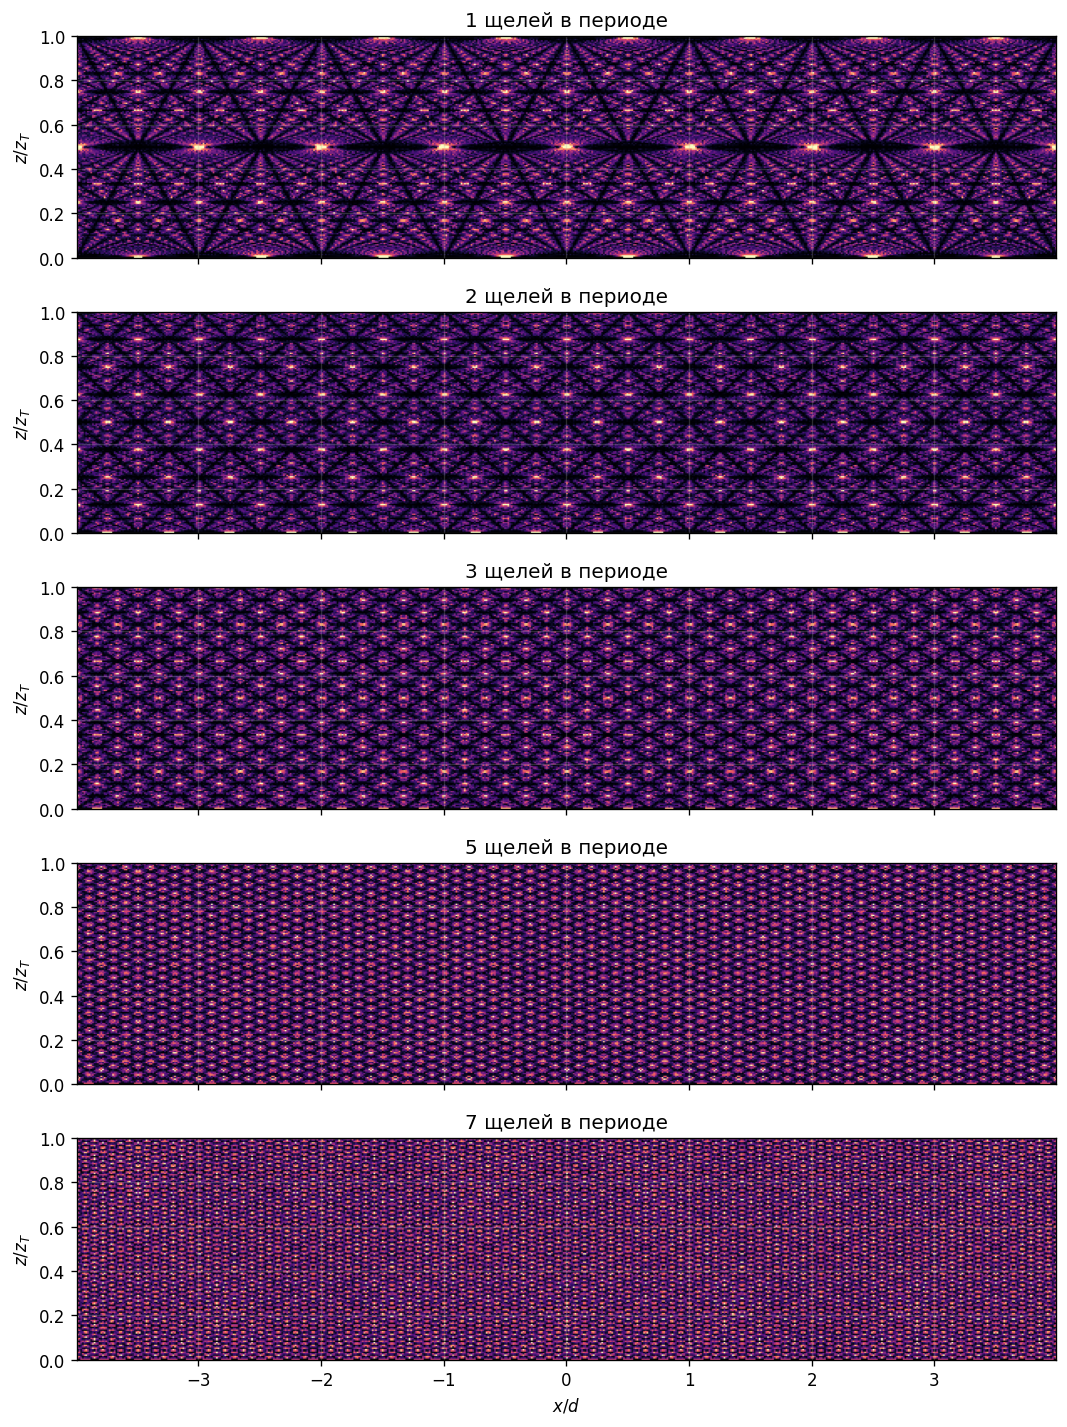

In [11]:
slit_counts_to_compare = [1, 2, 3, 5, 7]
comparison_slit_width = 0.08

gallery_grid = SimulationGrid(
    wavelength=wavelength,
    period=period,
    num_periods=28,
    nx=2048,
    nz=160,
)
gallery_z = np.linspace(0.0, gallery_grid.z_talbot, gallery_grid.nz)
old_model = model
model = "paraxial"

fig, axes = plt.subplots(len(slit_counts_to_compare), 1, figsize=(9, 2.4 * len(slit_counts_to_compare)), sharex=True, sharey=True)
if len(slit_counts_to_compare) == 1:
    axes = [axes]

for ax, count in zip(axes, slit_counts_to_compare):
    gallery_field = multi_slit_amplitude_grating(
        gallery_grid.x,
        period,
        slit_count=int(count),
        slit_width=min(comparison_slit_width, 0.75 / count),
    )
    gallery_carpet = talbot_carpet(gallery_field, gallery_grid, gallery_z)
    mask = np.abs(gallery_grid.x / period) <= x_window_periods / 2
    ax.imshow(
        gallery_carpet[:, mask],
        origin="lower",
        aspect="auto",
        extent=(gallery_grid.x[mask][0] / period, gallery_grid.x[mask][-1] / period, 0, 1),
        cmap="magma",
        vmin=0,
        vmax=np.percentile(gallery_carpet[:, mask], 99.5),
    )
    ax.set_ylabel(r"$z/z_T$")
    ax.set_title(f"{count} щелей в периоде")
axes[-1].set_xlabel(r"$x/d$")
fig.tight_layout()
plt.show()

model = old_model


## Галерея форм решеток

Эта ячейка показывает несколько типичных форм: амплитудные, фазовые и смешанную. Ее удобно использовать как обзор перед выбором конкретного случая в главной панели параметров.


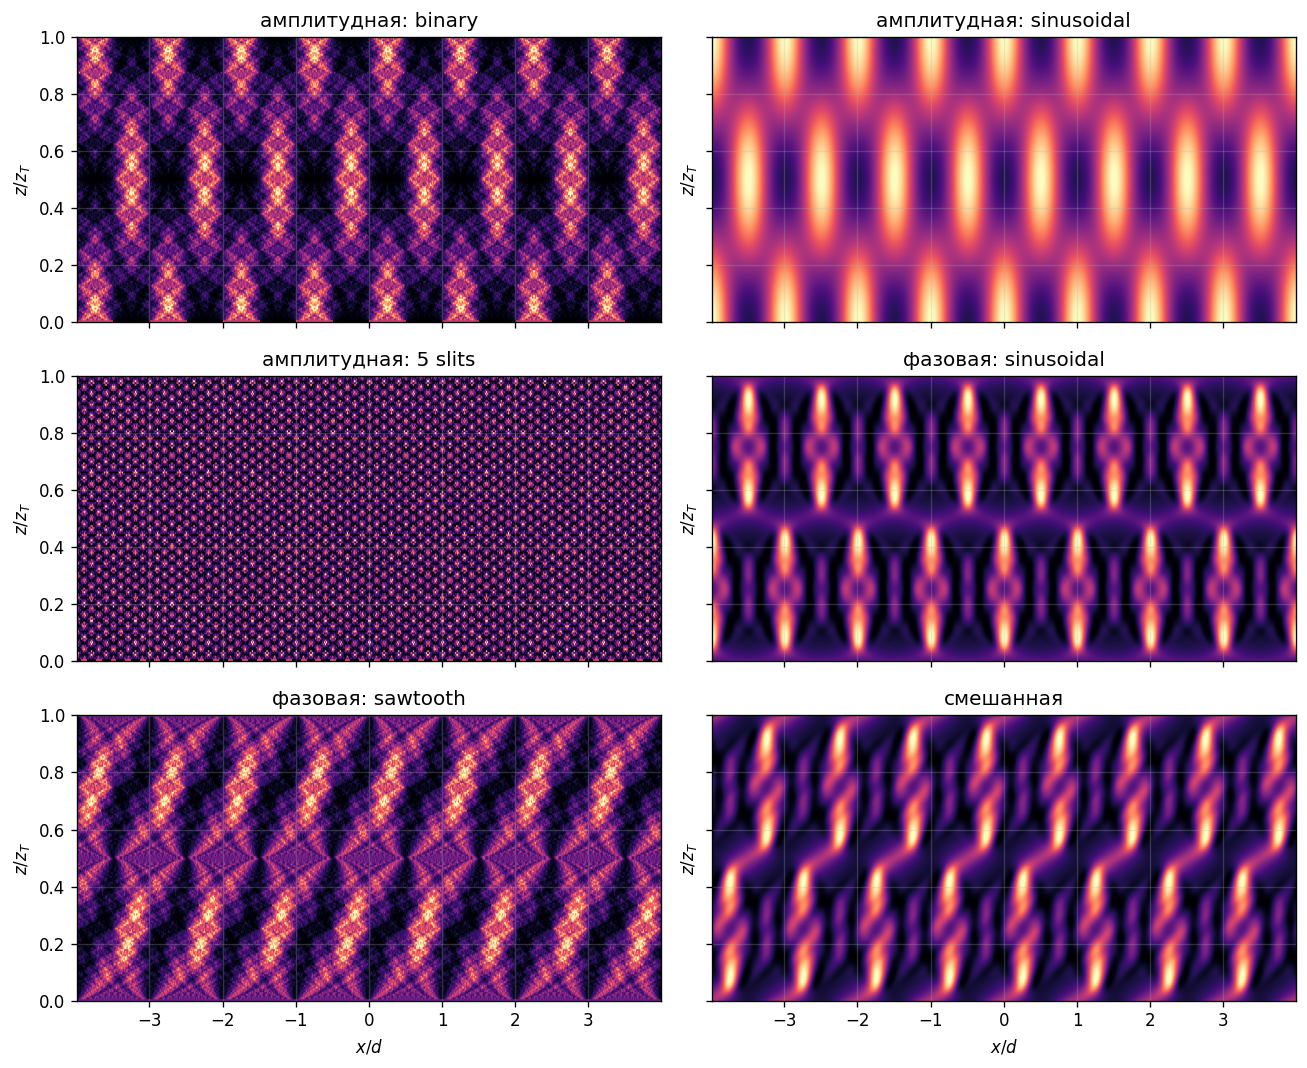

In [12]:
gallery_cases = [
    ("амплитудная: binary", binary_amplitude_grating(gallery_grid.x, period, fill=0.5)),
    ("амплитудная: sinusoidal", sinusoidal_amplitude_grating(gallery_grid.x, period, modulation=0.45)),
    ("амплитудная: 5 slits", multi_slit_amplitude_grating(gallery_grid.x, period, slit_count=5, slit_width=0.08)),
    ("фазовая: sinusoidal", sinusoidal_phase_grating(gallery_grid.x, period, phi0=phi0)),
    ("фазовая: пилообразная", blazed_phase_grating(gallery_grid.x, period, phase_depth=phase_depth)),
    ("смешанная", hybrid_amplitude_phase_grating(gallery_grid.x, period, modulation=modulation, phi0=phi0)),
]

old_model = model
model = "paraxial"
fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, (name, case_field) in zip(axes.ravel(), gallery_cases):
    case_carpet = talbot_carpet(case_field, gallery_grid, gallery_z)
    mask = np.abs(gallery_grid.x / period) <= x_window_periods / 2
    ax.imshow(
        case_carpet[:, mask],
        origin="lower",
        aspect="auto",
        extent=(gallery_grid.x[mask][0] / period, gallery_grid.x[mask][-1] / period, 0, 1),
        cmap="magma",
        vmin=0,
        vmax=np.percentile(case_carpet[:, mask], 99.5),
    )
    ax.set_title(name)
    ax.set_ylabel(r"$z/z_T$")
for ax in axes[-1, :]:
    ax.set_xlabel(r"$x/d$")
fig.tight_layout()
plt.show()
model = old_model


## Сравнение параксиальной и точной моделей

При $d \gg \lambda$ параксиальное приближение обычно почти совпадает с точным угловым спектром. Если уменьшать период до нескольких длин волн, разница становится заметной.


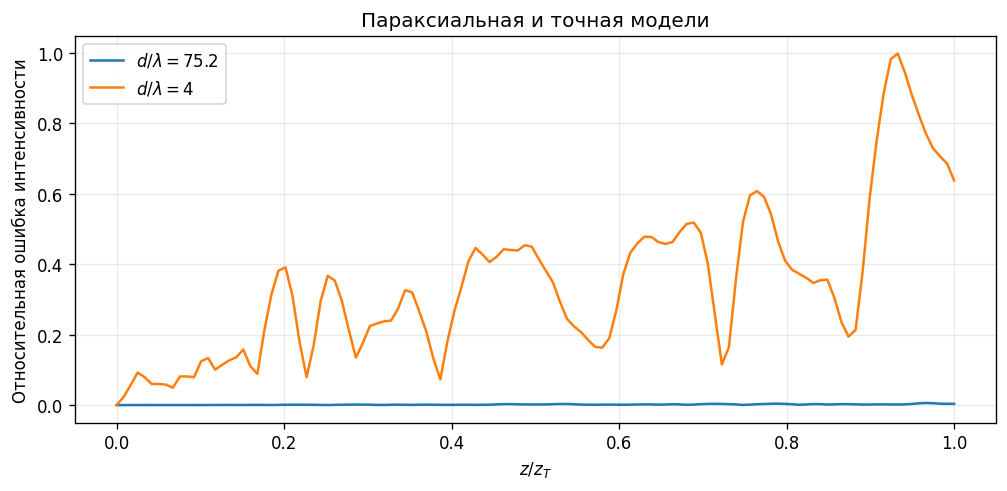

In [13]:
def paraxial_exact_error_curve(period_for_test, nx=2048, nz=120):
    local_grid = SimulationGrid(
        wavelength=wavelength,
        period=period_for_test,
        num_periods=36,
        nx=nx,
        nz=nz,
    )
    local_x = local_grid.x
    local_field = sinusoidal_phase_grating(local_x, period_for_test, phi0=phi0)
    local_z = np.linspace(0.0, local_grid.z_talbot, local_grid.nz)
    errors = []
    for z in local_z:
        up = propagate_paraxial(local_field, local_grid.dx, wavelength, float(z))
        ue = propagate_exact(local_field, local_grid.dx, wavelength, float(z), keep_evanescent=keep_evanescent)
        errors.append(relative_l2_error(intensity(up), intensity(ue)))
    return local_z / local_grid.z_talbot, np.asarray(errors)

z_default, err_default = paraxial_exact_error_curve(period)
z_small, err_small = paraxial_exact_error_curve(4 * wavelength)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(z_default, err_default, label=rf"$d/\lambda={period / wavelength:.1f}$")
ax.plot(z_small, err_small, label=r"$d/\lambda=4$")
ax.set_xlabel(r"$z/z_T$")
ax.set_ylabel("Относительная ошибка интенсивности")
ax.set_title("Параксиальная и точная модели")
ax.legend()
fig.tight_layout()
plt.show()


## Аналитический тест для синусоидальной амплитудной решетки

Для

$$t(x)=1+m\cos\left(\frac{2\pi x}{d}\right)$$

параксиальное решение имеет вид

$$A(x,z)=1+m\cos\left(\frac{2\pi x}{d}\right)\exp\left(-i\pi\lambda z/d^2\right).$$

Эта ячейка проверяет, что численный пропагатор воспроизводит формулу.


In [14]:
m_test = 0.3
z_test = 0.37 * zT
u_sin = sinusoidal_amplitude_grating(x, period, modulation=m_test)
numerical = propagate_paraxial(u_sin, grid.dx, wavelength, z_test)
analytical = 1.0 + m_test * np.cos(2 * np.pi * x / period) * np.exp(-1j * np.pi * wavelength * z_test / period**2)
print(f"Относительная L2-ошибка: {relative_l2_error(numerical, analytical):.3e}")


Относительная L2-ошибка: 1.488e-15


## Сохранение текущих рисунков

Если нужно сохранить текущий ковер, профиль, спектр и срезы в `figures/`, поменяйте `save_current = True` и выполните ячейку.


In [15]:
save_current = False

if save_current:
    tag = f"notebook_{grating_kind}_{profile}_{model}".replace(" ", "_")
    plot_transmission(field).savefig(FIGURES / f"{tag}_profile.png", bbox_inches="tight")
    plot_carpet(carpet, title=f"Ковер Талбота: {grating_kind}, {profile}, model={model}").savefig(FIGURES / f"{tag}_carpet.png", bbox_inches="tight")
    plot_spectrum(field).savefig(FIGURES / f"{tag}_spectrum.png", bbox_inches="tight")
    plot_slices(field).savefig(FIGURES / f"{tag}_slices.png", bbox_inches="tight")
    plt.close("all")
    print(f"Сохранено в {FIGURES}")
else:
    print("Сохранение выключено. Поставьте save_current = True, если нужно записать PNG.")


Сохранение выключено. Поставьте save_current = True, если нужно записать PNG.


## Как запустить полный проект

Из терминала в корне проекта:

```bash
python -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
python scripts/run_all.py
pytest
```

На Windows вместо `source .venv/bin/activate`:

```bash
.venv\Scripts\activate
```

Полный генератор `scripts/run_all.py` строит финальные картинки из README. Этот ноутбук удобнее для экспериментов и подбора параметров.
